**This notebook has been tested and designed to be run in Google Colab environment.**

# Requirements
Necessary update of the libraries.

In [13]:
!pip install git+https://github.com/huggingface/diffusers

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-rysvmtkg
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-rysvmtkg
  Resolved https://github.com/huggingface/diffusers to commit 708182958223612e285e03f1039dba8ea391a3ae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [14]:
!pip install --upgrade torchao

Fetch files for full reproducibility

In [15]:
# Esempio di come sarà la cella nel tuo notebook definitivo:
!mkdir -p lora
!wget https://raw.githubusercontent.com/Ric03aipy/Art-Director-Ghibli-style-generation/main/lora/train_text_to_image_lora.py -O lora/train_text_to_image_lora.py
!wget https://raw.githubusercontent.com/Ric03aipy/Art-Director-Ghibli-style-generation/main/lora/lora_accelerate_script.sh -O lora/lora_accelerate_script.sh

--2026-07-28 15:06:17--  https://raw.githubusercontent.com/Ric03aipy/Art-Director-Ghibli-style-generation/main/lora/train_text_to_image_lora.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-28 15:06:17 ERROR 404: Not Found.

--2026-07-28 15:06:17--  https://raw.githubusercontent.com/Ric03aipy/Art-Director-Ghibli-style-generation/main/lora/lora_accelerate_script.sh
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-07-28 15:06:17 ERROR 404: Not Found.



# Import

In [16]:
# general purpopse
from pathlib import Path
import os
import subprocess
import shutil
import json
from typing import List, Dict
from dataclasses import dataclass

# image handling
from PIL import Image
import matplotlib.pyplot as plt

# DL framework
import torch

# hugging face
from datasets import load_dataset, DatasetDict
from diffusers import StableDiffusionPipeline

try:
  from google.colab import files
except:
  print("Downloading files has been done on Colab. Please note if you're not running this colab on Google Colab you should adapt the download funciton after fine tuning.")

# Globals
- Paths
- Model and Dataset name
- Output and Save locations

In [17]:
ROOT = Path.cwd()

DATASET_NAME = "moving-j/ghibli-style-100"
DATASET_PATH = ROOT / "lora" / "gibli_lora_dataset"

# [optional]
CACHE_EXPLORATORY_PATH = ROOT / "lora" / "gibli_cache_dataset"

# [source (at the moment of writing): https://github.com/huggingface/diffusers/blob/main/examples/text_to_image/train_text_to_image_lora.py]
TXT2IMAGE_LORA_SCRIPT_PATH = ROOT / "lora" / "train_text_to_image_lora.py"

LORA_BASH_SCRIPT_PATH = ROOT / "lora" / "lora_accelerate_script.sh"

# model name from Hf
BASE_MODEL_NAME = "runwayml/stable-diffusion-v1-5"

# name of the .safetensors resulting file
OUTPUT_FILENAME = "lora_ghibli_model"

# name of the folder you want to save all the files produeced by the fine tuning
SAVING_PATH = ROOT / "lora" / "lora_ghibli_model"
LORA_WEIGHTS_PATH = SAVING_PATH / "pytorch_lora_weights.safetensors"

# Download data

In [ ]:
def download_data(ds_name:str, out_path:Path) -> DatasetDict:
  """Download the dataset in the specified path."""
  out_path.mkdir(parents=True, exist_ok=True)
  dataset = load_dataset(ds_name, cache_dir=out_path)
  return dataset

In [ ]:
dataset = download_data(DATASET_NAME, CACHE_EXPLORATORY_PATH)


README.md:   0%|          | 0.00/353 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.8MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/100 [00:00<?, ? examples/s]

# Data Exploration and Understanding
Here we see some info about the datset:
- a first understanding of the data structure
- an image
- the size of the images in the dataset --> the size are different, thus I'll resize them to have all 512x512 when building the dataset

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 100
    })
})

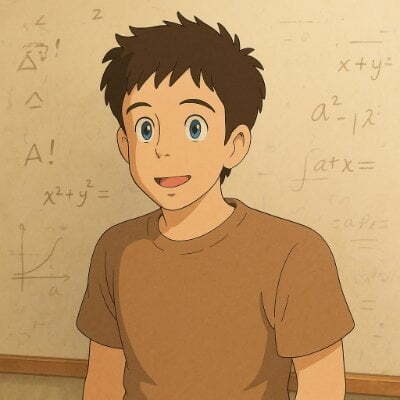

Image dimensions (width, height): (400, 400)


In [ ]:
# EXPLORATION CELL

train_set = dataset['train']

# Get the first image (which is already a PIL Image object)
first_image = train_set[0]["image"]

# Display the image (colab function)
display(first_image)

# Print the image dimensions (width, height)
print(f"Image dimensions (width, height): {first_image.size}")

In [ ]:
NUM_TO_EXPLORE = 10
for i in range(NUM_TO_EXPLORE):
  el:Image = train_set[i]["image"]
  print(el.size)


(400, 400)
(736, 736)
(735, 551)
(736, 735)
(736, 1104)
(642, 642)
(600, 338)
(681, 685)
(736, 1104)
(600, 600)


# Building the dataset for LoRa

LoRa programs and *diffuser* scripts require a specific strucutre in the dataset.

For LoRa programs you need a folder with ll images and text files with the same name (e.g `img_00.png` and `text_00.txt`).

For *diffuser* scripts instead you need a folder with all images and a *.jsonl* metadata file, where each image is associated to its caption.

**Here I provide both the function to build the dataset but I carry on only the script pathway.**

You will find all the images `img_{number}.png` and the `metadata.jsonl` in the folder `lora/gibli_lora_dataset/` after having run the next cells. All images in the dataset are ensured to be $512\times 512$ and RGB encoded.



In [ ]:
def build_lora_dataset_for_graphical_interface(dataset:DatasetDict, out_path:Path) -> None:
  """
  Extract images and text from the dataset.
  Build the training data in the specified path in the form (imgX, txtX).
  This is good for graphical interfaces like Kohya_ss.
  """
  out_path.mkdir(parents=True, exist_ok=True)
  train_set = dataset['train']
  for idx, sample in enumerate(train_set):
    img = sample["image"]
    img = img.convert("RGB")
    img = img.resize(size=(512,512))
    txt = sample["text"]
    img.save(out_path / f"img_{idx}.png")
    with open(out_path / f"txt_{idx}.txt", "w", encoding="utf-8") as f:
      f.write(txt)


def build_lora_dataset(dataset:DatasetDict, out_path:Path) -> None:
  """
  Extract images and text from the dataset.
  Build the training data in the specified path as a jsonl metadata file.
  This is good for LoRA scripts (accelerate).
  """
  out_path.mkdir(parents=True, exist_ok=True)
  train_set = dataset['train']
  data = []
  for idx, sample in enumerate(train_set):
    img = sample["image"]
    img = img.convert("RGB")
    img = img.resize(size=(512,512))
    txt = sample["text"]
    img.save(out_path / f"img_{idx}.png")
    data.append({"file_name": f"img_{idx}.png", "text": txt})

  with open(out_path / "metadata.jsonl", "w", encoding="utf-8") as f:
    for line in data:
      json.dump(line, f)
      f.write("\n")


def load_metadata(in_path:Path) -> List[Dict]:
  """Reads the jsonl metadata file."""
  with open(in_path / "metadata.jsonl", "r", encoding="utf-8") as f:
    data = [json.loads(line) for line in f]
  return data


In [ ]:
build_lora_dataset(dataset, DATASET_PATH)

### Some safety checks

In [ ]:
data = load_metadata(DATASET_PATH)

In [ ]:
data[0:2]

[{'file_name': 'img_0.png',
  'text': 'The image is a Ghibli-style cartoon of a young man standing in front of a chalkboard covered in mathematical equations and symbols. The character has short brown hair, blue eyes, and is wearing a brown t-shirt.'},
 {'file_name': 'img_1.png',
  'text': 'The image features a character from the movie Spirited Away in Ghibli style: a large, gray rat with wide eyes, and a small bird with large, round eyes and a black beak perched on top of its head. The characters are set against a plain, light background.'}]

In [ ]:
def check_image_size(path:Path) -> bool:
  """Check if all the images in the provided path have the same size. """
  img_paths = Path.glob(path, "*.png")
  img_paths = list(img_paths)
  print(f"Analysing {len(img_paths)} images...")
  w, h = Image.open(img_paths[0]).size
  print(f"Size of the images: {w}, {h}")
  for img_path in img_paths:
    img = Image.open(img_path)
    if img.size != (w, h):
      return False
  return True

In [ ]:
if check_image_size(DATASET_PATH): print("All the images have the same size.")
else: print("Not all the images have the same size.")

Analysing 100 images...
Size of the images: 512, 512
All the images have the same size.


# Model

Let's load the model, and test how it works before LoRa.

Before running the fine tuning make sure you have the necessary file in the right places:
- `train_text_to_image_lora.py` must be in the folder `lora`
- `lora_accelerate_script.sh` must be in the folder `lora`



In [ ]:
pipe = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda")


/usr/local/lib/python3.12/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

[<PIL.Image.Image image mode=RGB size=512x512 at 0x7C6D40165190>]


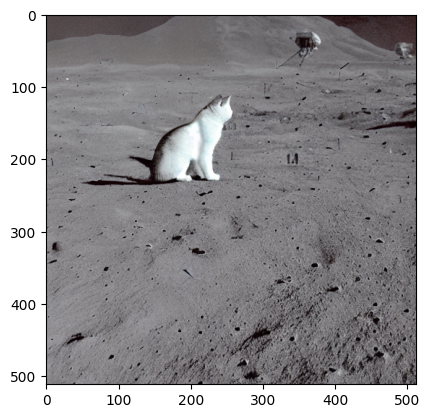

In [ ]:
prompt = "A cat on the moon."
imgs = pipe(prompt).images
# print(imgs) # images as List[PIL.Image]
plt.imshow(imgs[0])

In [ ]:
# requirement of external files
if not Path.exists(TXT2IMAGE_LORA_SCRIPT_PATH):
  raise FileNotFoundError(f"File {TXT2IMAGE_LORA_SCRIPT_PATH.stem}.py not found. Please upload in the folder: {TXT2IMAGE_LORA_SCRIPT_PATH.parent}")
if not Path.exists(LORA_BASH_SCRIPT_PATH):
  raise FileNotFoundError(f"File {LORA_BASH_SCRIPT_PATH.stem}.sh not found. Please upload in the folder: {script_path.parent}.")


In [ ]:
# I've had compatibility issue: Windows/Linux (Colab)

# To ensure compatibility run this cell after having loaded the accelerate script
!sed -i 's/\r$//' /content/lora/lora_accelerate_script.sh

# Running the LoRa
To keep thing restricted to one file so to simplify the flow, the *accelerate* script is run as a `subprocess`.

The cell after running the fine tuning allow to download all the results. Although though to begin run on Colab, the function `shutil.make_archive` will create a zip archive also in a local environment. Therefore altough you will read "downlaod skipped", it's something referred only to Colab, results will be saved anyway in `lora/lora_ghibli_model`


In [ ]:
def run_fine_tuning_script(script_path:Path, debug:bool) -> bool:
  """Run the fine tuning script."""
  print("Fine tuning (LoRA) started.")
  try:
    res = subprocess.run(
        args = ["bash", str(script_path)],
        cwd = str(script_path.parent),
        check = True, # raise an Exception if the subprocess fails
        text = True,  # convert the output from bytes to text
        capture_output = debug # if True you have stdout and err, but not the progress bar to understand how much the fine tuning will take
    )
    print(res.stdout)
    print("Fine tuning (LoRA) completed.")
  except subprocess.CalledProcessError as e:
    print(f"Raised error: {e}\n.Error code: {e.returncode}")
    if debug: print(f"Error: {e.stderr}")
    return False
  print("Fine tuning (accelerate) finished.")
  return True

In [ ]:
run_fine_tuning_script(LORA_BASH_SCRIPT_PATH, debug=False)

Fine tuning (LoRA) started.
None
Fine tuning (LoRA) completed.
Fine tuning (accelerate) finished.


True

In [ ]:
# SAVE EVERYTHING PRODUCED BY THE FINE TUNING (3h 25 min on Colab Free Tier Resources)

try:
  # if running locally this is enough to save the files
  shutil.make_archive(OUTPUT_FILENAME, 'zip', SAVING_PATH)
  print(f"Compressing the folder '{OUTPUT_FILENAME}'...")

  try:
    # automatically download files from Colab
    from google.colab import files
    files.download(f'{OUTPUT_FILENAME}.zip')
  except ImportError:
    print("Not running in Google Colab, skipping file download.")

except Exception as e:
  print(f"An error occurred during archiving or downloading: {e}")


Compressing the folder 'lora_ghibli_model'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test
To see if the style tranfer has been effective, let's ask the model before and after lora weights LoRa weights loading to generate an image with the same prompt.

To ensure the random initial noise of the underlying diffusion model is the same, the seed has been fixed at the same value before the generation of both.

If you have downloaded the .safetensors file from the repo and want to skip the training, make sure to create the folder lora/lora_ghibli_model in your environment and upload the file exactly inside there before running this cell.

I've provided a dataclass `PathInfo` to easily handle the paths and choose where to save files.



In [18]:
from huggingface_hub import hf_hub_download

def download_safetensors_from_hf(repo_id: str, filename: str, local_dir: Path) -> Path:
  """
  Downloads a .safetensors file from a Hugging Face model repository.
  """
  local_dir.mkdir(parents=True, exist_ok=True)
  downloaded_path = hf_hub_download(
      repo_id=repo_id,
      filename=filename,
      local_dir=local_dir
  )
  print(f"Downloaded '{filename}' to {downloaded_path}")
  return Path(downloaded_path)


In [19]:
download_safetensors_from_hf(
    repo_id="RicB03/sd1.5-ghibli-style-lora",
    filename="pytorch_lora_weights.safetensors",
    local_dir=SAVING_PATH
)

Downloaded 'pytorch_lora_weights.safetensors' to /content/lora/lora_ghibli_model/pytorch_lora_weights.safetensors


PosixPath('/content/lora/lora_ghibli_model/pytorch_lora_weights.safetensors')

In [22]:
SEED = 123

@dataclass()
class PathInfo:
  """Compact data structure to store saving configuration."""
  base_dest: Path
  base_dest_name: str
  lora_dest: Path
  lora_dest_name: str


def make_comparison(prompt:str, negative_prompt:str, base_model:str, lora_weights_path:Path, path_info: PathInfo) -> None:
  """
  Instantiate and create the same image with the model before fine tuning and after fine tuning.
  This function is meant for test, not to produce images in batch: it loads the model at each call.
  """

  if not path_info.base_dest.exists():
    path_info.base_dest.mkdir(parents=True, exist_ok=True)
  if not path_info.lora_dest.exists():
    path_info.lora_dest.mkdir(parents=True, exist_ok=True)

  print("Loading the base model...")

  pipe = StableDiffusionPipeline.from_pretrained(
      base_model,
      torch_dtype=torch.float16
  ).to("cuda")

  # ensure that both the model start from the same noise
  generator = torch.Generator("cuda").manual_seed(SEED)

  img_base: Image = pipe(
      prompt=prompt,
      negative_prompt=negative_prompt,
      generator=generator
  ).images[0]
  img_base.save(path_info.base_dest / f"{path_info.base_dest_name}.png")

  print("Loading the LoRA weights...")
  pipe.load_lora_weights(lora_weights_path)

  # ensure that both the model start from the same noise
  generator = torch.Generator("cuda").manual_seed(SEED)

  img_lora: Image = pipe(
      prompt=prompt,
      negative_prompt=negative_prompt,
      generator=generator
  ).images[0]
  img_lora.save(path_info.lora_dest / f"{path_info.lora_dest_name}.png")

  print("Images saved in the following paths:")
  print(f"Base model: {path_info.base_dest}")
  print(f"LoRA model: {path_info.lora_dest}")


In [23]:
path_params = PathInfo(
    base_dest = Path.cwd() / "lora" / "ghibli_base_model",
    base_dest_name = "base_test_0",
    lora_dest = Path.cwd() / "lora" / "ghibli_lora_model",
    lora_dest_name = "lora_test_0"
)

prompt = "A girl on the side of a waterfall, seen from the back, looking at a beautiful landscape, high quality, masterpiece."
negative_prompt = "ugly, gross, bad anatomy, bad hands, missing fingers, extra digit, fewer digits, worst quality, low quality, deformed face, mutated, poorly drawn"

make_comparison(
    prompt,
    negative_prompt,
    BASE_MODEL_NAME,
    LORA_WEIGHTS_PATH,
    path_params
)

Loading the base model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Loading the LoRA weights...


No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

Images saved in the following paths:
Base model: /content/lora/ghibli_base_model
LoRA model: /content/lora/ghibli_lora_model
